In [112]:
## Importing Libraries
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing
from IPython.core.interactiveshell import InteractiveShell
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
# from collections import defaultdicta
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

In [113]:
## Importing CSV file

df = pd.read_csv("day.csv")

In [114]:
## Shape of the dataframe

df.shape

(730, 16)

## Dataset has 730 rows and 16 columns

In [115]:
## Inspecting top 5 records of the dataset

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [116]:
# Spliting dteday into day,month,year
k = df['dteday'].str.split('-',expand=True)

In [117]:
df[['day','month',"year"]]=k

In [118]:
#Dropping column dteday
df.drop(['dteday'],axis=1,inplace=True)

In [119]:
#Dropping column yr,mnth
df.drop(['yr','mnth'],axis=1,inplace=True)

In [120]:
## Checking datatypes of each column in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   season      730 non-null    int64  
 2   holiday     730 non-null    int64  
 3   weekday     730 non-null    int64  
 4   workingday  730 non-null    int64  
 5   weathersit  730 non-null    int64  
 6   temp        730 non-null    float64
 7   atemp       730 non-null    float64
 8   hum         730 non-null    float64
 9   windspeed   730 non-null    float64
 10  casual      730 non-null    int64  
 11  registered  730 non-null    int64  
 12  cnt         730 non-null    int64  
 13  day         730 non-null    object 
 14  month       730 non-null    object 
 15  year        730 non-null    object 
dtypes: float64(4), int64(9), object(3)
memory usage: 91.4+ KB


## Except one column, all other are either float or integer type.

# DATA QUALITY CHECK

### Check for NULL/MISSING values

In [121]:
# Checking null values column wise

df.isnull().sum()

instant       0
season        0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
day           0
month         0
year          0
dtype: int64

In [122]:
# Checking null values row wise

df.isnull().sum()

instant       0
season        0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
day           0
month         0
year          0
dtype: int64

# No null values found

In [123]:
# Checking columns of dataframe

df.columns

Index(['instant', 'season', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt',
       'day', 'month', 'year'],
      dtype='object')

In [124]:
# Total columns

len(df.columns)

16

In [125]:
#Checking columns

df.describe(include='all')

,instant,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day,month,year
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730,730,730
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,12,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,07,2019
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,62,365
mean,365.500000,2.498630,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849,NaN,NaN,NaN
std,210.877136,1.110184,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647,NaN,NaN,NaN
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000,NaN,NaN,NaN
25%,183.250000,2.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000,NaN,NaN,NaN
50%,365.500000,3.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000,NaN,NaN,NaN
75%,547.750000,3.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000,NaN,NaN,NaN


In [126]:
# Inspecting columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   season      730 non-null    int64  
 2   holiday     730 non-null    int64  
 3   weekday     730 non-null    int64  
 4   workingday  730 non-null    int64  
 5   weathersit  730 non-null    int64  
 6   temp        730 non-null    float64
 7   atemp       730 non-null    float64
 8   hum         730 non-null    float64
 9   windspeed   730 non-null    float64
 10  casual      730 non-null    int64  
 11  registered  730 non-null    int64  
 12  cnt         730 non-null    int64  
 13  day         730 non-null    object 
 14  month       730 non-null    object 
 15  year        730 non-null    object 
dtypes: float64(4), int64(9), object(3)
memory usage: 91.4+ KB


In [127]:
# Dropping Instant columns

df.drop('instant',axis=1,inplace=True)

In [128]:
#Inspecting Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   holiday     730 non-null    int64  
 2   weekday     730 non-null    int64  
 3   workingday  730 non-null    int64  
 4   weathersit  730 non-null    int64  
 5   temp        730 non-null    float64
 6   atemp       730 non-null    float64
 7   hum         730 non-null    float64
 8   windspeed   730 non-null    float64
 9   casual      730 non-null    int64  
 10  registered  730 non-null    int64  
 11  cnt         730 non-null    int64  
 12  day         730 non-null    object 
 13  month       730 non-null    object 
 14  year        730 non-null    object 
dtypes: float64(4), int64(8), object(3)
memory usage: 85.7+ KB


In [129]:
#Checking seasons column

df['season'].value_counts()

3    188
2    184
1    180
4    178
Name: season, dtype: int64

In [130]:
#Changing season columns value

def ass_season(x):
    return x.map({
        1:"spring", 2:"summer", 3:"fall", 4:"winter"
    })
df[['season']] = df[['season']].apply(ass_season)
df['season'].value_counts()

fall      188
summer    184
spring    180
winter    178
Name: season, dtype: int64

In [131]:
#Checking weathersit column
df['weathersit'].value_counts()

1    463
2    246
3     21
Name: weathersit, dtype: int64

In [132]:
#Changing weathersit columns value

def ass_weathersit(x):
    return x.map({
        1:"clear", 2:"mist", 3:"fall", 4:"light_snow"
    })
df[['weathersit']] = df[['weathersit']].apply(ass_weathersit)
df['weathersit'].value_counts()

clear    463
mist     246
fall      21
Name: weathersit, dtype: int64

In [133]:
#Checking weekday columns value

df['weekday'].value_counts()

2    105
1    105
6    104
5    104
4    104
3    104
0    104
Name: weekday, dtype: int64

In [134]:
#Changing weekday columns value

def ass_weekday(x):
    return x.map({
        0:'Sun',1:'Mon',2:'Tues',3:'Wed',4:'Thu',5:'Fri',6:'Sat'
    })
df[['weekday']] = df[['weekday']].apply(ass_weekday)
df['weekday'].value_counts()

Mon     105
Tues    105
Sun     104
Sat     104
Wed     104
Fri     104
Thu     104
Name: weekday, dtype: int64

In [135]:
df.sample()

,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day,month,year
539,fall,0,Mon,1,clear,30.476653,33.7127,47.9167,9.750175,2551,4340,6891,24,06,2019


# Data Visualization

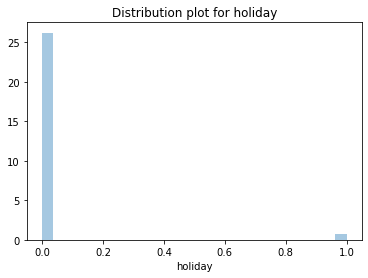

-----------------------------------------------------x--------------------------------------------------


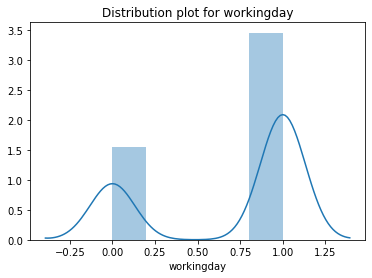

-----------------------------------------------------x--------------------------------------------------


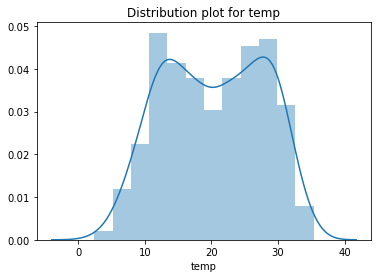

-----------------------------------------------------x--------------------------------------------------


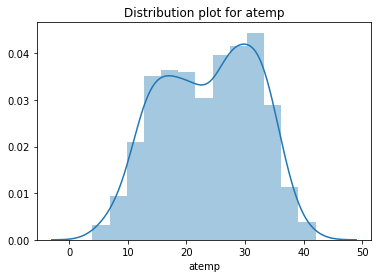

-----------------------------------------------------x--------------------------------------------------


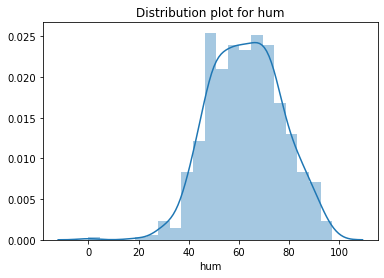

-----------------------------------------------------x--------------------------------------------------


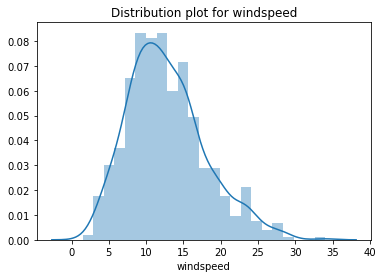

-----------------------------------------------------x--------------------------------------------------


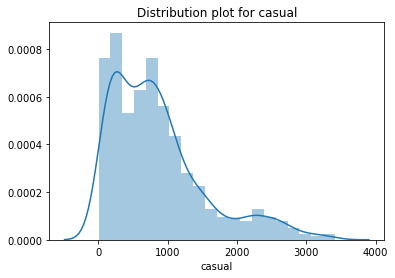

-----------------------------------------------------x--------------------------------------------------


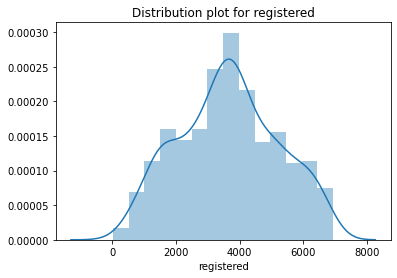

-----------------------------------------------------x--------------------------------------------------


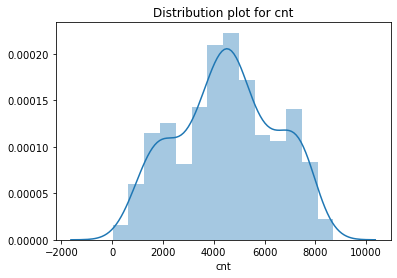

-----------------------------------------------------x--------------------------------------------------


In [136]:
x = list(df.describe().columns)

for i in x:
    sns.distplot(df[i])
    plt.title("Distribution plot for "+ i)
    plt.show();
    print("-----------------------------------------------------x--------------------------------------------------")

# Numerical columns cnt,registered,windspeed,casual,hum,atemp,temp have normal distribution

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    object 
 1   holiday     730 non-null    int64  
 2   weekday     730 non-null    object 
 3   workingday  730 non-null    int64  
 4   weathersit  730 non-null    object 
 5   temp        730 non-null    float64
 6   atemp       730 non-null    float64
 7   hum         730 non-null    float64
 8   windspeed   730 non-null    float64
 9   casual      730 non-null    int64  
 10  registered  730 non-null    int64  
 11  cnt         730 non-null    int64  
 12  day         730 non-null    object 
 13  month       730 non-null    object 
 14  year        730 non-null    object 
dtypes: float64(4), int64(5), object(6)
memory usage: 85.7+ KB


In [138]:
# Taking all categorical column in a variable
df_categorical = df.select_dtypes(exclude=['float64','int64','datetime64'])
x=list(df_categorical.columns)
x

['season', 'weekday', 'weathersit', 'day', 'month', 'year']

In [139]:
#Inspecting the length of categorical column
len(df_categorical.columns)

6

-----------------------------------------------------x--------------------------------------------------


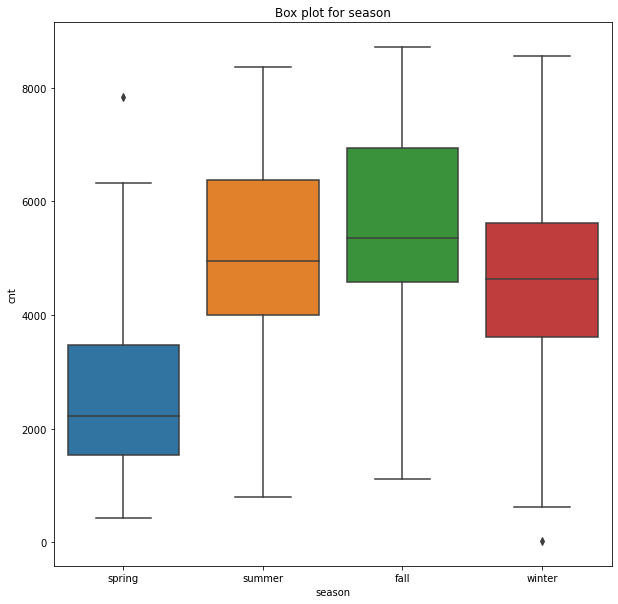

-----------------------------------------------------x--------------------------------------------------


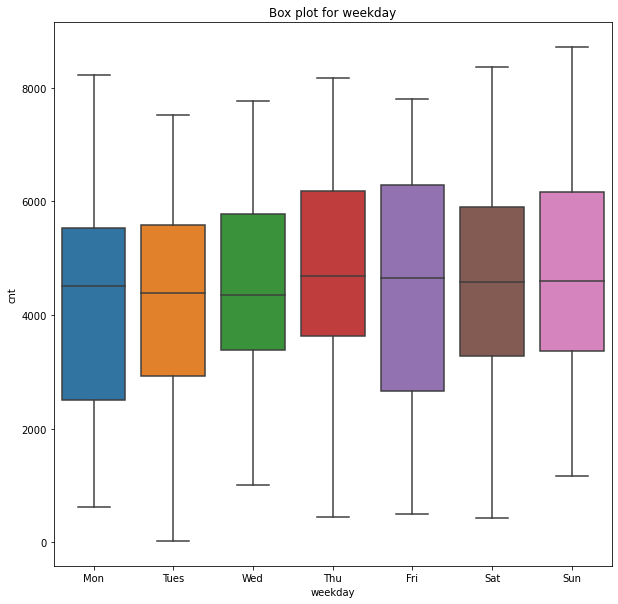

-----------------------------------------------------x--------------------------------------------------


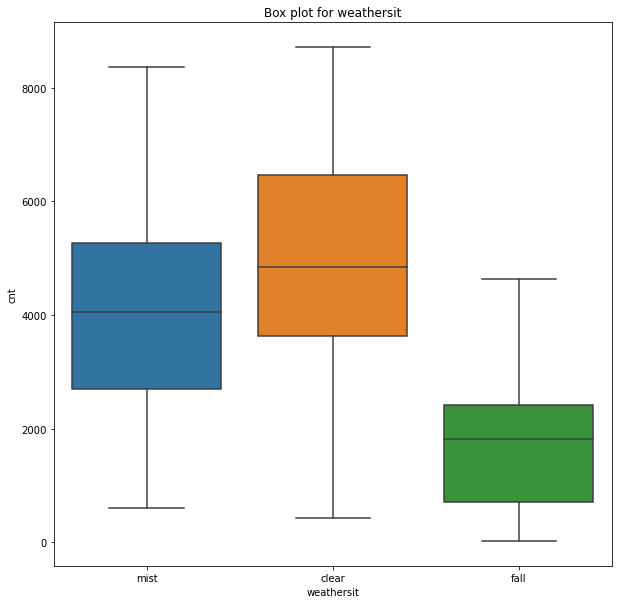

-----------------------------------------------------x--------------------------------------------------


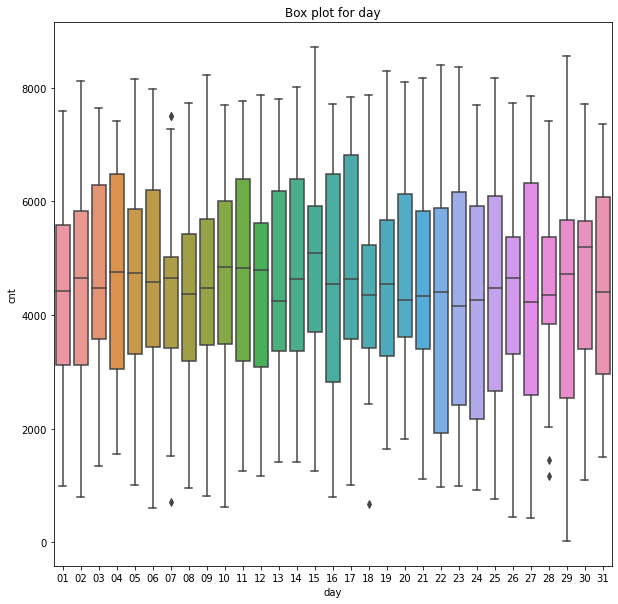

-----------------------------------------------------x--------------------------------------------------


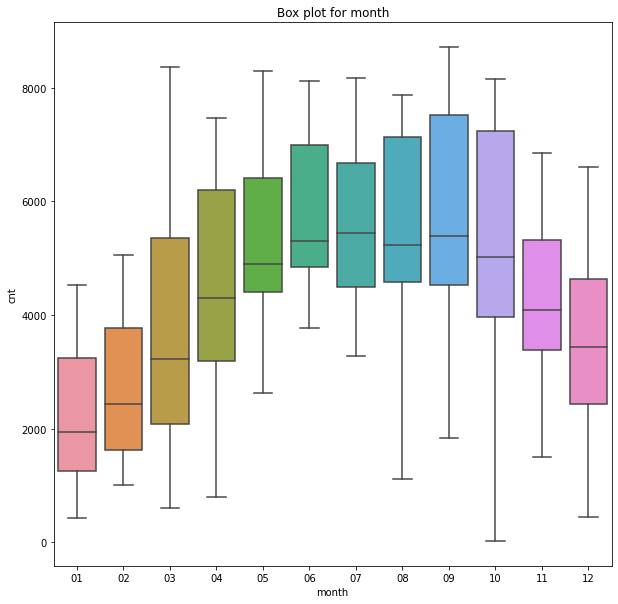

-----------------------------------------------------x--------------------------------------------------


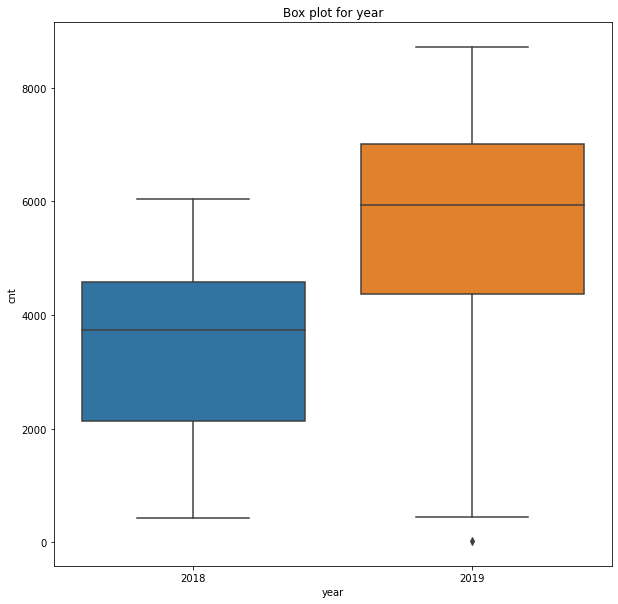

In [140]:

    
    for i in df_categorical:
        plt.figure(figsize=(10,10))
        sns.boxplot(x=i, y='cnt', data=df)
        plt.title("Box plot for "+ i)
        print("-----------------------------------------------------x--------------------------------------------------")
        plt.show()

###### There were 6 categorical variables in the dataset. I used Box plot to study their effect on the dependent variable (‘cnt’) . The inference that I could derive were: - season: Almost 32% of the bike booking were happening in season3 with a median of over 5000 booking (for the period of 2 years). This was followed by season2 & season4 with 27% & 25% of total booking. This indicates, season can be a good predictor for the dependent variable. - mnth: Almost 10% of the bike booking were happening in the months 5,6,7,8 & 9 with a median of over 4000 booking per month. This indicates, mnth has some trend for bookings and can be a good predictor for the dependent variable. - weathersit: Almost 67% of the bike booking were happening during ‘weathersit1 with a median of close to 5000 booking (for the period of 2 years). This was followed by weathersit2 with 30% of total booking. This indicates, weathersit does show some trend towards the bike bookings can be a good predictor for the dependent variable. - holiday: Almost 97.6% of the bike booking were happening when it is not a holiday which means this data is clearly biased. This indicates, holiday can not be a good predictor for the dependent variable. - weekday: weekday variable shows very close trend (between 13.5%-14.8% of total booking on all days of the week) having their independent medians between 4000 to 5000 bookings. This variable can have some or no influence towards the predictor. I will let the model decide if this needs to be added or not. - workingday: Almost 69% of the bike booking were happening in ‘workingday’ with a median of close to 5000 booking (for the period of 2 years). This indicates, workingday can be a good predictor for the dependent variable.

In [141]:
# Visualizing Numerical Variables

IntVariableList = ['casual','registered','cnt']

for var in IntVariableList:
    df[var] = df[var].astype('float')

In [142]:
#Taking numeriacl column in a variable
df_numeric = df.select_dtypes(include=['float64'])
df_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


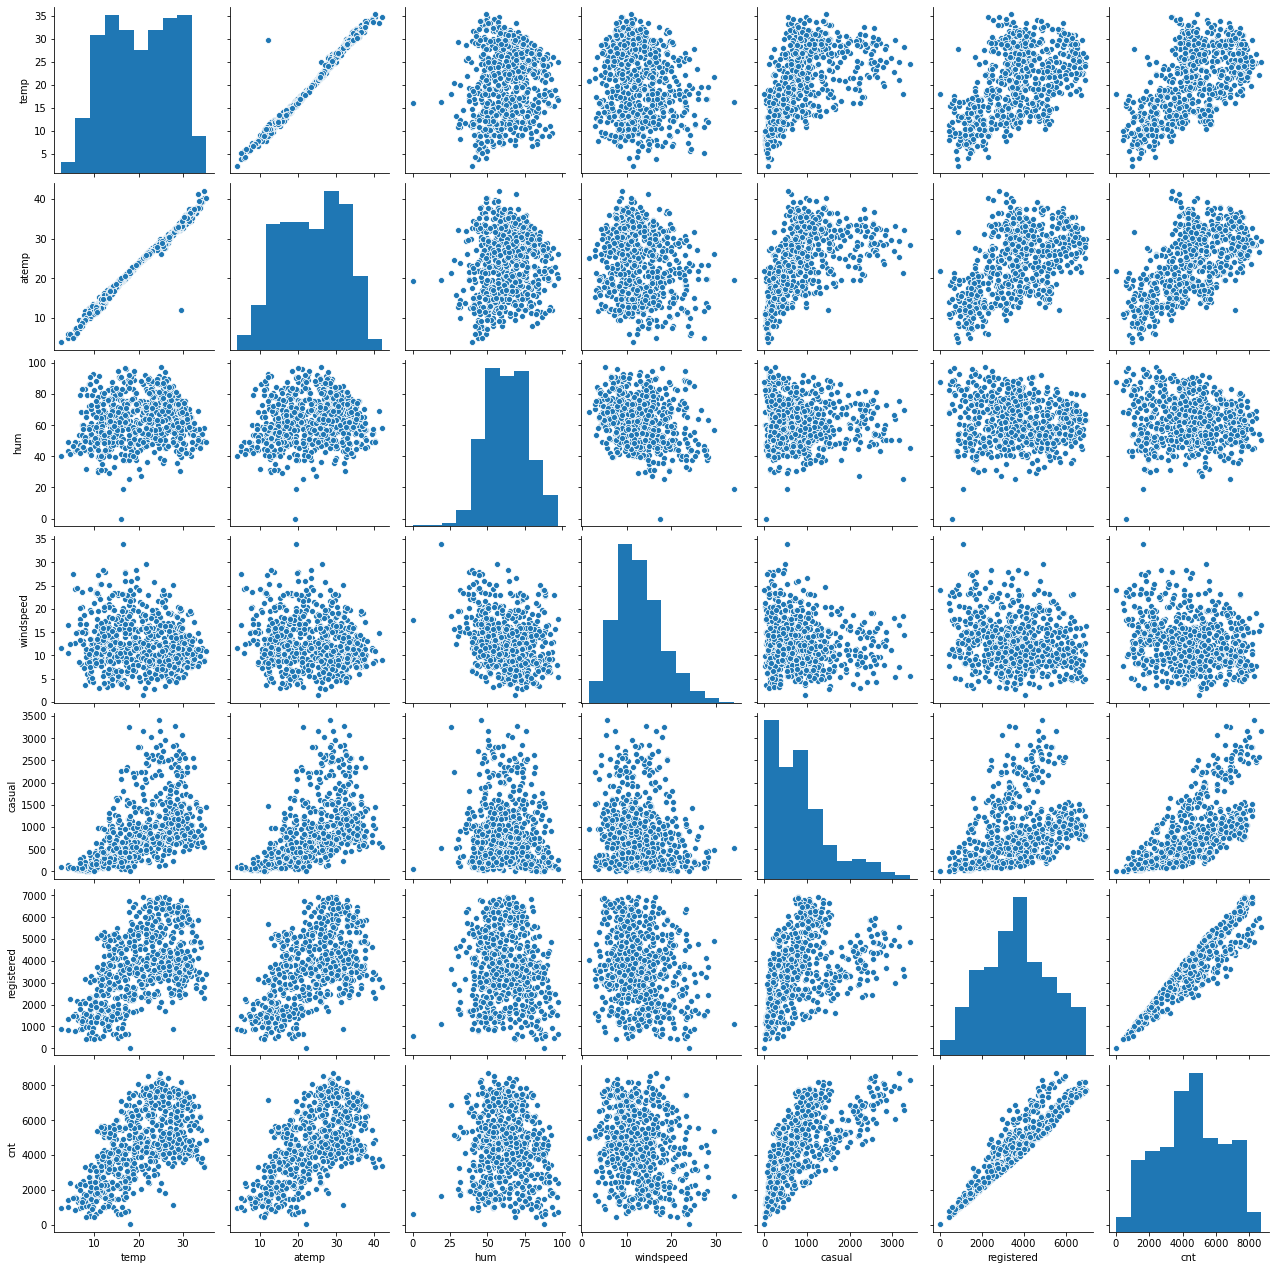

In [143]:
#Pair-plot of numerical column
sns.pairplot(df_numeric)
plt.show();

# The above Pair-Plot tells us that there is a LINEAR RELATION between 'temp','atemp','registered' and 'cnt' 

In [144]:
#Corealtion between numerical columns
cor = df_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


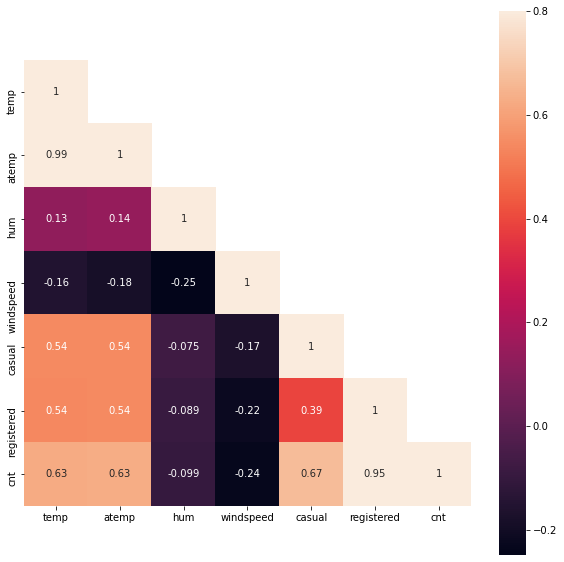

In [145]:
#Heat map of numerical columns
mask = np.array(cor)
mask[ np.tril_indices_from(mask) ] = False
fig, ax = plt.subplots()
fig.set_size_inches(10,10)
sns.heatmap(cor, mask=mask, vmax=0.8, square=True, annot=True);

# The heatmap clearly shows which all variable are multicollinear in nature, and which variable have high collinearity with the target variable

In [146]:
# Coverting day,month,year into integer
df[['day','month','year']] = df[['day','month','year']].astype(int)

In [147]:
df.head()

,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day,month,year
0,spring,0,Mon,1,mist,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0,1,1,2018
1,spring,0,Tues,1,mist,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0,2,1,2018
2,spring,0,Wed,1,clear,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0,3,1,2018
3,spring,0,Thu,1,clear,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0,4,1,2018
4,spring,0,Fri,1,clear,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0,5,1,2018


In [148]:
df.select_dtypes(['object']).columns

Index(['season', 'weekday', 'weathersit'], dtype='object')

In [149]:
cat_cols=df.select_dtypes(['object']).columns
for col in cat_cols:
    freqs=df[col].value_counts()
    k=freqs.index[freqs>5][:-1]
    for cat in k:
        name=col+'_'+cat
        df[name]=(df[col]==cat).astype(int)
    del df[col]
    print(col)

season
weekday
weathersit


In [150]:
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,day,...,season_summer,season_spring,weekday_Mon,weekday_Tues,weekday_Sun,weekday_Sat,weekday_Wed,weekday_Fri,weathersit_clear,weathersit_mist
0,0,1,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0,1,...,0,1,1,0,0,0,0,0,0,1
1,0,1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0,2,...,0,1,0,1,0,0,0,0,0,1
2,0,1,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0,3,...,0,1,0,0,0,0,1,0,1,0
3,0,1,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0,4,...,0,1,0,0,0,0,0,0,1,0
4,0,1,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0,5,...,0,1,0,0,0,0,0,1,1,0


# SPLITTING THE DATA

In [151]:
# dropping registered column
df.drop(['registered'],axis=1,inplace=True)

In [152]:

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size = 0.2)

In [153]:
x_train = df_train.drop(['cnt'],axis=1)
y_train = df_train['cnt']

x_test = df_train.drop(['cnt'],axis=1)
y_test = df_train['cnt']

In [154]:
x_test.shape

(584, 21)

In [155]:
y_test.shape

(584,)

In [156]:
x_train.describe()

,holiday,workingday,temp,atemp,hum,windspeed,casual,day,month,year,...,season_summer,season_spring,weekday_Mon,weekday_Tues,weekday_Sun,weekday_Sat,weekday_Wed,weekday_Fri,weathersit_clear,weathersit_mist
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,...,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,0.034247,0.703767,20.248465,23.651596,62.722635,12.784133,842.494863,15.758562,6.690068,2018.506849,...,0.244863,0.238014,0.147260,0.152397,0.123288,0.143836,0.143836,0.140411,0.642123,0.328767
std,0.182018,0.456986,7.504324,8.179687,14.592614,5.328871,682.243373,8.746767,3.485058,0.500382,...,0.430375,0.426233,0.354669,0.359714,0.329049,0.351224,0.351224,0.347711,0.479787,0.470168
min,0.000000,0.000000,2.424346,3.953480,0.000000,1.500244,9.000000,1.000000,1.000000,2018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,13.828962,16.918900,51.572900,9.000445,316.750000,8.000000,4.000000,2018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,20.021673,23.800525,62.562500,12.041441,709.500000,16.000000,7.000000,2019.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,1.000000,26.803740,30.398263,73.281250,15.749623,1074.750000,23.000000,10.000000,2019.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,35.328347,42.044800,97.250000,34.000021,3252.000000,31.000000,12.000000,2019.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# RESCALING THE FEATURES

In [157]:
from sklearn.preprocessing import StandardScaler

In [158]:
scaler = StandardScaler()


In [159]:
# Checking the values before scaling
x_train.head()

,holiday,workingday,temp,atemp,hum,windspeed,casual,day,month,year,...,season_summer,season_spring,weekday_Mon,weekday_Tues,weekday_Sun,weekday_Sat,weekday_Wed,weekday_Fri,weathersit_clear,weathersit_mist
227,0,1,28.734153,32.29185,57.8333,15.834043,721.0,16,8,2018,...,0,0,0,0,0,0,0,0,1,0
172,0,1,30.066653,34.69145,70.7500,11.541554,661.0,22,6,2018,...,0,0,0,0,0,0,0,1,1,0
314,1,0,13.290847,15.34085,44.6250,21.083225,440.0,11,11,2018,...,0,0,0,0,1,0,0,0,1,0
161,0,1,29.725000,33.90190,65.4583,10.374950,1729.0,11,6,2018,...,1,0,1,0,0,0,0,0,1,0
119,0,1,19.372500,23.20105,50.3333,15.750025,1965.0,30,4,2018,...,1,0,1,0,0,0,0,0,1,0


In [160]:
var = ['temp', 'atemp','hum', 'windspeed']

x_train[var] = scaler.fit_transform(x_train[var])
x_test[var] = scaler.transform(x_test[var])

In [161]:
x_train.head()

,holiday,workingday,temp,atemp,hum,windspeed,casual,day,month,year,...,season_summer,season_spring,weekday_Mon,weekday_Tues,weekday_Sun,weekday_Sat,weekday_Wed,weekday_Fri,weathersit_clear,weathersit_mist
227,0,1,1.131743,1.057212,-0.335343,0.572828,721.0,16,8,2018,...,0,0,0,0,0,0,0,0,1,0
172,0,1,1.309459,1.350824,0.550569,-0.233378,661.0,22,6,2018,...,0,0,0,0,0,0,0,1,1,0
314,1,0,-0.927943,-1.016893,-1.241255,1.558718,440.0,11,11,2018,...,0,0,0,0,1,0,0,0,1,0
161,0,1,1.263893,1.254216,0.187630,-0.452488,1729.0,11,6,2018,...,1,0,1,0,0,0,0,0,1,0
119,0,1,-0.116828,-0.055128,-0.849742,0.557048,1965.0,30,4,2018,...,1,0,1,0,0,0,0,0,1,0


# RFE

In [162]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [163]:
# Running RFE with the output number of the variable equal to 15
lm = LinearRegression()
lm.fit(x_train, y_train)

rfe = RFE(lm, 15)             # running RFE
rfe = rfe.fit(x_train, y_train)

In [165]:
list(zip(x_train.columns,rfe.support_,rfe.ranking_))

[('holiday', True, 1),
 ('workingday', True, 1),
 ('temp', True, 1),
 ('atemp', False, 3),
 ('hum', False, 2),
 ('windspeed', True, 1),
 ('casual', False, 7),
 ('day', False, 6),
 ('month', False, 4),
 ('year', True, 1),
 ('season_fall', True, 1),
 ('season_summer', True, 1),
 ('season_spring', True, 1),
 ('weekday_Mon', True, 1),
 ('weekday_Tues', True, 1),
 ('weekday_Sun', True, 1),
 ('weekday_Sat', True, 1),
 ('weekday_Wed', True, 1),
 ('weekday_Fri', False, 5),
 ('weathersit_clear', True, 1),
 ('weathersit_mist', True, 1)]

In [166]:
col = x_train.columns[rfe.support_]
col


Index(['holiday', 'workingday', 'temp', 'windspeed', 'year', 'season_fall',
       'season_summer', 'season_spring', 'weekday_Mon', 'weekday_Tues',
       'weekday_Sun', 'weekday_Sat', 'weekday_Wed', 'weathersit_clear',
       'weathersit_mist'],
      dtype='object')

In [167]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = x_train[col]

# VIF Check

###### Model 1

In [168]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,year,278.18
1,workingday,169.47
11,weekday_Sat,35.28
10,weekday_Sun,29.75
13,weathersit_clear,24.26
14,weathersit_mist,12.94
0,holiday,6.92
5,season_fall,4.01
2,temp,3.34
7,season_spring,2.39


In [169]:
import statsmodels.api as sm

# Add a constant
X_train_lm1 = sm.add_constant(X_train_rfe)

# Create a first fitted model
lr1 = sm.OLS(y_train, X_train_lm1).fit()

In [170]:
# Check the parameters obtained

lr1.params


const              -4.143143e+06
holiday            -1.129024e+03
workingday         -5.870228e+02
temp                8.983050e+02
windspeed          -1.729266e+02
year                2.054518e+03
season_fall        -7.273838e+02
season_summer      -3.896130e+02
season_spring      -1.527809e+03
weekday_Mon        -2.841298e+02
weekday_Tues       -2.721544e+02
weekday_Sun        -5.117063e+02
weekday_Sat        -5.515200e+02
weekday_Wed        -1.711299e+02
weathersit_clear    2.222534e+03
weathersit_mist     1.585124e+03
dtype: float64

In [171]:
# Print a summary of the linear regression model obtained
print(lr1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     174.0
Date:                Mon, 25 Jan 2021   Prob (F-statistic):          6.20e-201
Time:                        20:20:40   Log-Likelihood:                -4746.2
No. Observations:                 584   AIC:                             9524.
Df Residuals:                     568   BIC:                             9594.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -4.143e+06   1.41e+05  

##### Model 2

# Dropping workingday as it has High vif and p-value

In [172]:
X_train_new = X_train_rfe.drop(["workingday"], axis = 1)

In [173]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,year,38.18
12,weathersit_clear,24.25
13,weathersit_mist,12.94
4,season_fall,4.01
1,temp,3.33
5,season_summer,2.38
6,season_spring,2.37
8,weekday_Tues,1.56
11,weekday_Wed,1.56
7,weekday_Mon,1.52


In [174]:
# Add a constant
X_train_lm2 = sm.add_constant(X_train_new)

# Create a first fitted model
lr2 = sm.OLS(y_train, X_train_lm2).fit()
# Check the parameters obtained

lr2.params

const              -4.155466e+06
holiday            -6.355407e+02
temp                9.018893e+02
windspeed          -1.748415e+02
year                2.060334e+03
season_fall        -7.254833e+02
season_summer      -3.885436e+02
season_spring      -1.515850e+03
weekday_Mon        -2.846524e+02
weekday_Tues       -2.673319e+02
weekday_Sun         6.178298e+01
weekday_Sat         2.858879e+01
weekday_Wed        -1.606869e+02
weathersit_clear    2.214892e+03
weathersit_mist     1.582362e+03
dtype: float64

In [175]:
# Print a summary of the linear regression model obtained
print(lr2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     186.3
Date:                Mon, 25 Jan 2021   Prob (F-statistic):          8.11e-202
Time:                        20:20:43   Log-Likelihood:                -4746.8
No. Observations:                 584   AIC:                             9524.
Df Residuals:                     569   BIC:                             9589.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -4.155e+06   1.41e+05  

# Model 3

#  Removing the variable 'year' based on its Very High vif value

In [177]:
X_train_new = X_train_new.drop(["year"], axis = 1)

In [178]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
11,weathersit_clear,4.57
3,season_fall,3.79
1,temp,3.23
12,weathersit_mist,2.78
5,season_spring,2.36
4,season_summer,2.29
7,weekday_Tues,1.56
10,weekday_Wed,1.55
6,weekday_Mon,1.49
9,weekday_Sat,1.48


In [179]:
# Add a constant
X_train_lm3 = sm.add_constant(X_train_new)

# Create a first fitted model
lr3 = sm.OLS(y_train, X_train_lm3).fit()
# Check the parameters obtained

lr3.params

const               2669.774675
holiday             -600.692195
temp                1068.834160
windspeed           -168.840815
season_fall        -1016.426304
season_summer       -519.244838
season_spring      -1377.937019
weekday_Mon         -314.732338
weekday_Tues        -311.777613
weekday_Sun          -67.059563
weekday_Sat         -126.641823
weekday_Wed         -139.931971
weathersit_clear    3040.978573
weathersit_mist     2341.529387
dtype: float64

In [180]:
# Print a summary of the linear regression model obtained
print(lr3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     52.95
Date:                Mon, 25 Jan 2021   Prob (F-statistic):           4.11e-89
Time:                        20:21:20   Log-Likelihood:                -5017.7
No. Observations:                 584   AIC:                         1.006e+04
Df Residuals:                     570   BIC:                         1.012e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2669.7747    337.373  

# Model 4

In [182]:
#dropping  weekday_Sun  as it has high vif value      
X_train_new = X_train_new.drop(["weekday_Sun"], axis = 1)

In [183]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
10,weathersit_clear,3.94
3,season_fall,3.78
1,temp,3.21
11,weathersit_mist,2.43
5,season_spring,2.35
4,season_summer,2.28
9,weekday_Wed,1.40
7,weekday_Tues,1.39
6,weekday_Mon,1.35
8,weekday_Sat,1.34


In [184]:
# Add a constant
X_train_lm4 = sm.add_constant(X_train_new)

# Create a first fitted model
lr4 = sm.OLS(y_train, X_train_lm4).fit()

In [185]:
# Check the parameters obtained

lr4.params

const               2662.516411
holiday             -603.691047
temp                1070.787060
windspeed           -169.179585
season_fall        -1018.518005
season_summer       -521.257025
season_spring      -1374.306964
weekday_Mon         -294.664880
weekday_Tues        -290.994541
weekday_Sat         -106.659602
weekday_Wed         -119.210244
weathersit_clear    3028.165002
weathersit_mist     2327.829028
dtype: float64

In [186]:
# Print a summary of the linear regression model obtained
print(lr4.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     57.44
Date:                Mon, 25 Jan 2021   Prob (F-statistic):           5.65e-90
Time:                        20:21:59   Log-Likelihood:                -5017.7
No. Observations:                 584   AIC:                         1.006e+04
Df Residuals:                     571   BIC:                         1.012e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2662.5164    336.506  

# Model 5

In [188]:
#Dropping weekday_Thu column as it has high p-value
X_train_new = X_train_new.drop(["weekday_Sat"], axis = 1)

In [189]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,season_fall,3.77
9,weathersit_clear,3.67
1,temp,3.21
5,season_spring,2.35
4,season_summer,2.28
10,weathersit_mist,2.27
8,weekday_Wed,1.31
7,weekday_Tues,1.29
6,weekday_Mon,1.26
2,windspeed,1.11


In [190]:
# Add a constant
X_train_lm5 = sm.add_constant(X_train_new)

# Create a first fitted model
lr5 = sm.OLS(y_train, X_train_lm5).fit()

In [191]:
# Check the parameters obtained

lr5.params


const               2639.105876
holiday             -602.124693
temp                1069.916109
windspeed           -169.870040
season_fall        -1022.917332
season_summer       -522.754719
season_spring      -1378.229495
weekday_Mon         -267.205839
weekday_Tues        -263.550670
weekday_Wed          -91.753757
weathersit_clear    3026.871981
weathersit_mist     2325.002354
dtype: float64

In [192]:
# Print a summary of the linear regression model obtained
print(lr5.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     62.69
Date:                Mon, 25 Jan 2021   Prob (F-statistic):           8.50e-91
Time:                        20:22:20   Log-Likelihood:                -5018.0
No. Observations:                 584   AIC:                         1.006e+04
Df Residuals:                     572   BIC:                         1.011e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2639.1059    334.318  

# Model 6

In [193]:
#Dropping weekday_Wed column as it has high p-value
X_train_new = X_train_new.drop(["weekday_Wed"], axis = 1)

In [194]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,season_fall,3.77
8,weathersit_clear,3.46
1,temp,3.21
5,season_spring,2.35
4,season_summer,2.28
9,weathersit_mist,2.17
7,weekday_Tues,1.23
6,weekday_Mon,1.21
2,windspeed,1.11
0,holiday,1.05


In [195]:
# Add a constant
X_train_lm6 = sm.add_constant(X_train_new)

# Create a first fitted model
lr6 = sm.OLS(y_train, X_train_lm6).fit()
# Check the parameters obtained

lr6.params

const               2631.691786
holiday             -634.777590
temp                1070.869493
windspeed           -170.956585
season_fall        -1023.874499
season_summer       -522.877401
season_spring      -1377.393121
weekday_Mon         -249.440929
weekday_Tues        -243.627275
weathersit_clear    3016.124149
weathersit_mist     2314.825673
dtype: float64

In [196]:
# Print a summary of the linear regression model obtained
print(lr6.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     69.01
Date:                Mon, 25 Jan 2021   Prob (F-statistic):           1.16e-91
Time:                        20:22:37   Log-Likelihood:                -5018.1
No. Observations:                 584   AIC:                         1.006e+04
Df Residuals:                     573   BIC:                         1.011e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2631.6918    333.852  

# Model 7

In [197]:
#Dropping weekday_Mon,weekday_Tues,weekday_Fri,holiday column as it has high p-value
X_train_new = X_train_new.drop(["weekday_Tues"], axis = 1)
X_train_new = X_train_new.drop(["weekday_Mon"], axis = 1)
X_train_new = X_train_new.drop(["holiday"], axis = 1)

In [198]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,season_fall,3.77
0,temp,3.21
5,weathersit_clear,3.15
4,season_spring,2.35
3,season_summer,2.28
6,weathersit_mist,2.02
1,windspeed,1.11


In [199]:
# Add a constant
X_train_lm7 = sm.add_constant(X_train_new)

# Create a first fitted model
lr7 = sm.OLS(y_train, X_train_lm7).fit()
# Check the parameters obtained

lr7.params

const               2590.170547
temp                1079.185155
windspeed           -174.216878
season_fall        -1017.321117
season_summer       -511.994675
season_spring      -1379.323305
weathersit_clear    2954.220939
weathersit_mist     2259.550051
dtype: float64

In [200]:
# Print a summary of the linear regression model obtained
print(lr7.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     96.45
Date:                Mon, 25 Jan 2021   Prob (F-statistic):           8.74e-93
Time:                        20:23:11   Log-Likelihood:                -5022.4
No. Observations:                 584   AIC:                         1.006e+04
Df Residuals:                     576   BIC:                         1.010e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2590.1705    334.398  

# VALIDATE ASSUMPTIONS

In [201]:
y_train_pred = lr1.predict(X_train_lm1)

Text(0.5, 0, 'Errors')

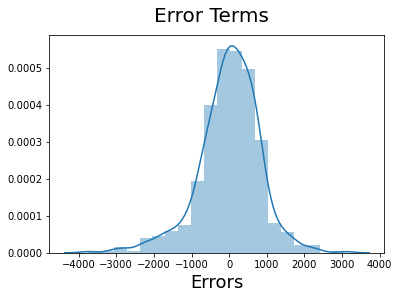

In [202]:
res = y_train-y_train_pred

# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((res), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                 
plt.xlabel('Errors', fontsize = 18)  

# We could see that the Residuals are normally distributed. Hence our assumption for Linear Regression is valid.

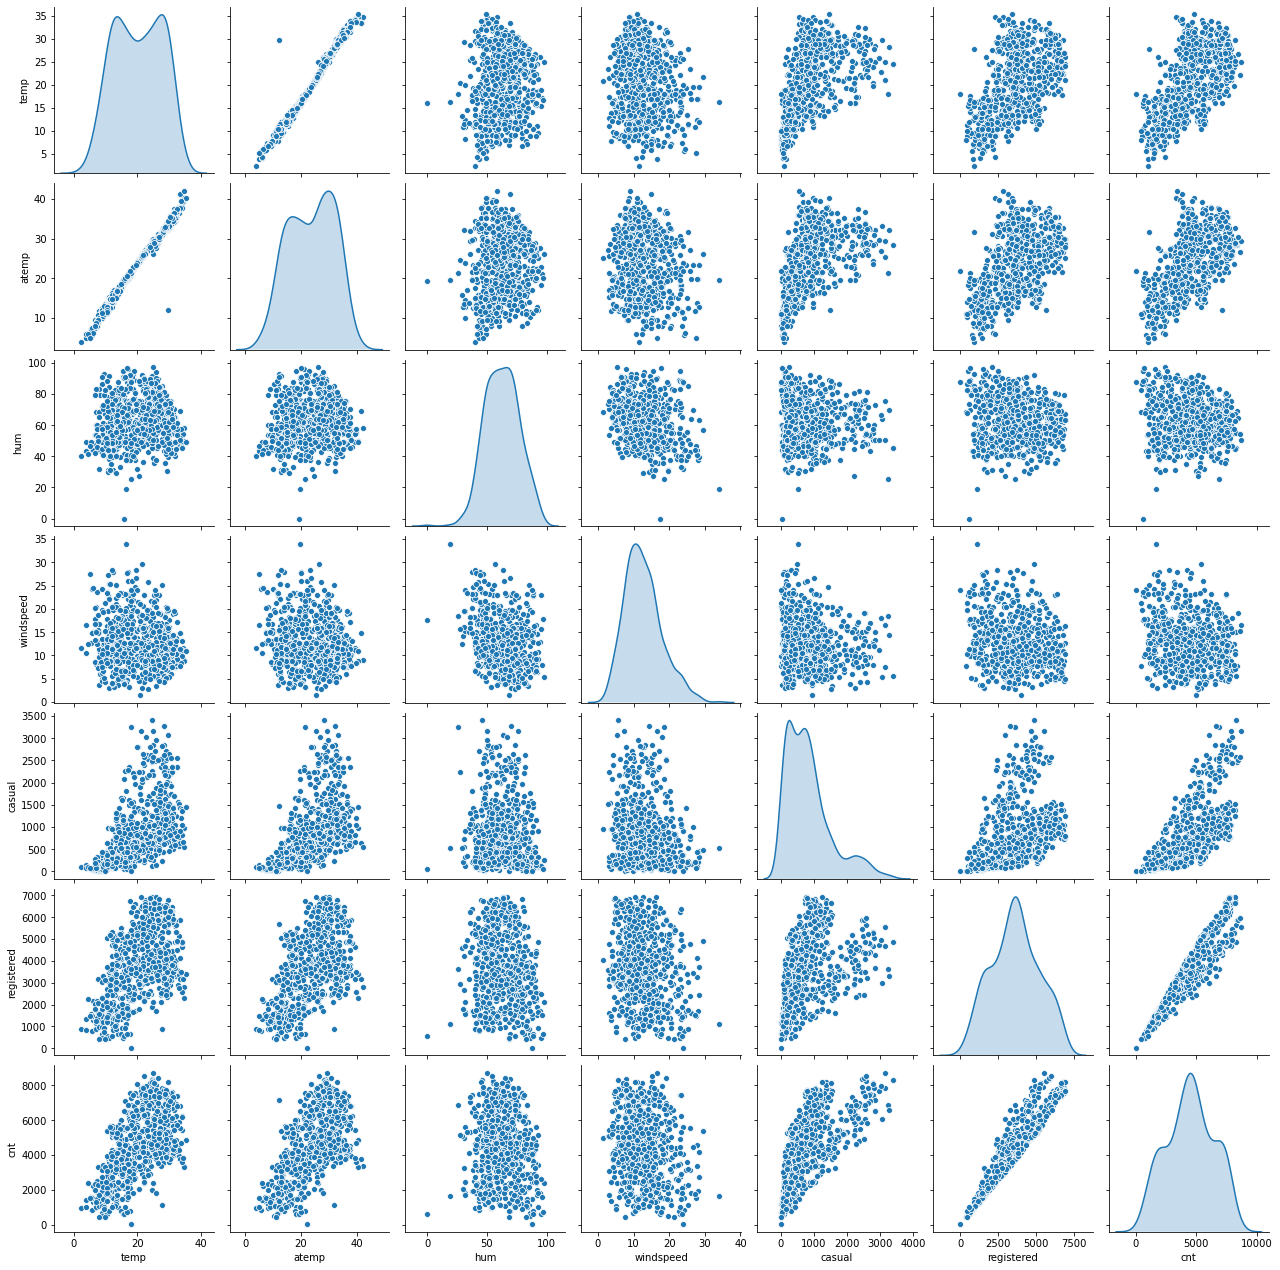

In [203]:
sns.pairplot(df_numeric, diag_kind='kde')
plt.show();

# Using the pair plot, we could see there is a linear relation between temp and atemp variable with the predictor ‘cnt’.

In [204]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,season_fall,3.77
0,temp,3.21
5,weathersit_clear,3.15
4,season_spring,2.35
3,season_summer,2.28
6,weathersit_mist,2.02
1,windspeed,1.11


# From the VIF calculation we could find that there is no multicollinearity existing between the predictor variables, as all the values are within permissible range of below 5

# BUILDING A LINEAR MODEL

In [205]:
from sklearn.linear_model import LinearRegression

In [206]:
lm = LinearRegression()
lm.fit(x_train, y_train)

LinearRegression()

In [207]:
y_pred = lm.predict(x_test)

# R^2 Value for TEST

In [208]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8824945797732633

# Adjusted R^2 Value for TEST

In [209]:
r2=0.8792684395356112

In [210]:
# Get the shape of X_test

x_test.shape

(584, 21)

In [211]:
# n is number of rows in X

n = x_test.shape[0]


# Number of features (predictors, p) is the shape along axis 1
p = x_test.shape[1]

# We find the Adjusted R-squared using the formula

adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.8747571178812479

# FINAL RESULT COMPARISON: --- - Train R^2 :0.824 - Train Adjusted R^2 :0.828 --- - Test R^2 :0.879 - Test Adjusted R^2 :0.874 --- - This seems to be a really good model that can very well 'Generalize' various datasets.

# FINAL REPORT

###### As per our final Model, the top 3 predictor variables that influences the bike booking are: --- - Temperature (temp) - A coefficient value of ‘0.5636’ indicated that a unit increase in temp variable increases the bike hire numbers by 0.5636 units. - Weather Situation 3 (weathersit_3) - A coefficient value of ‘-0.3070’ indicated that, w.r.t Weathersit1, a unit increase in Weathersit3 variable decreases the bike hire numbers by 0.3070 units. - Year (yr) - A coefficient value of ‘0.2308’ indicated that a unit increase in yr variable increases the bike hire numbers by 0.2308 units. --- SO IT IS RECOMMENDED TO GIVE THESE VARIABLES UTMOST IMPORTANCE WHILE PLANNING, TO ACHIEVE MAXIMUM BOOKING. --- The next best features that can also be considered are - - season_4: - A coefficient value of ‘0.128744’ indicated that w.r.t season_1, a unit increase in season_4 variable increases the bike hire numbers by 0.128744 units. - windspeed: - A coefficient value of ‘-0.155191’ indicated that, a unit increase in windspeed variable decreases the bike hire numbers by 0.155191 units. --- NOTE: - The details of weathersit_1 & weathersit_3 - weathersit_1: Clear, Few clouds, Partly cloudy, Partly cloudy - weathersit_3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds - The details of season1 & season4 - season1: spring - season4: winter